In [1]:
from telescope import *
from spectrograph import *
from detector import *
from spectralmodels import Sky, get_list_of_stellar_models, get_stellar_spectrum
from etc.etc import simulate_1D_spectrum, simulate_2D_spectrum, SpecETC

from pathlib import Path
from astropy.table import Table
import numpy as np
from matplotlib import pyplot as plt

In [2]:
models = get_list_of_stellar_models(verbose=True)
sptype = 'G5V'
mag = 12
star = get_stellar_spectrum(sptype=sptype, mag=mag)
sky = Sky(seeing=3.0*u.arcsec, mag=18)

O ['O8III', 'O9V', 'O5V']
B ['B1-2III', 'B2II', 'B2IV', 'B6IV', 'B5I', 'B5II', 'B8V', 'B8I', 'B0V', 'B5-7V', 'B3V', 'B1V', 'B5III', 'B9III', 'B0I']
A ['A0V', 'A5III', 'A0III', 'A5V', 'A2V', 'A3V', 'A4-7IV', 'A0IV', 'A0I']
F ['F8V', 'F5V', 'F0I', 'F0V', 'F0III', 'F8IV', 'F2V', 'F5I', 'F5IV', 'F2II', 'F5III', 'F8I', 'F0-2IV', 'F0II']
G ['G8I', 'G8III', 'G5II', 'G8V', 'G0III', 'G2V', 'G2IV', 'G5III', 'G5IV', 'G0I', 'G5I', 'G0IV', 'G8IV', 'G0V', 'G5V']
K ['K3III', 'K1IV', 'K2I', 'K0III', 'K7V', 'K0IV', 'K0V', 'K4I', 'K5III', 'K2V', 'K5V', 'K3-4II', 'K3IV', 'K0-1II']
M ['M5V', 'M2V', 'M10III', 'M5III', 'M3II', 'M2I', 'M0V', 'M0III', 'M4V']


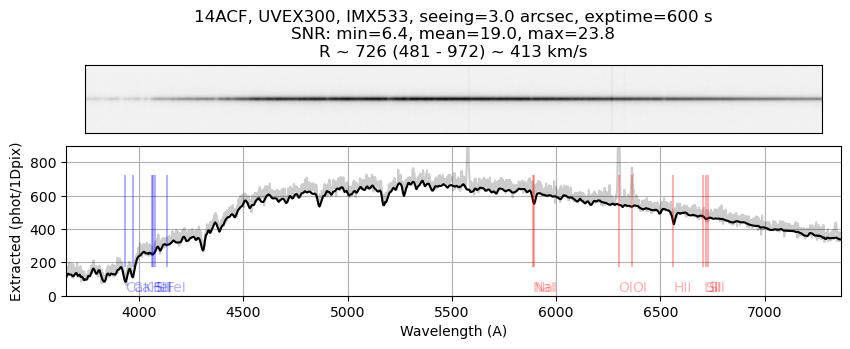

In [3]:
IMX533.exptime = 600*u.second
im, spec, var = SpecETC(star, sky, ACF14, UVEX300, IMX533, plot=True)

In [4]:
def compare_instrumentation(instrumentation, sptype='G5V', mag=12):
    plt.figure(figsize=(12,4))
    plt.title(f'{sptype} star mag={mag:.1f}')
    peakSNR = 0
    wavmin = 3500
    wavmax = 8800
    for i,inst in enumerate(instrumentation):
        tel, spec, det, exptime, deltam = inst
        det.exptime = exptime
        spec.set_detector(det)
        star = get_stellar_spectrum(sptype=sptype, mag=mag+deltam)
        im, spectra, variance = SpecETC(star, sky, tel, spec, det, plot=False)
        R = np.mean(spec.R)
        SNR = spectra/variance**0.5
        label = f"dm={deltam:+4.2f} {tel.name}+{spec.name}+{det.name}@{det.exptime:.0f}: SNR={max(SNR):.1f}, R~{R:.0f}"
        plt.plot(spec.binset, SNR, alpha=0.5, label=label)
        peakSNR = peakSNR if max(SNR) <= peakSNR else max(SNR)
    
    
    lines_file = Path('.') / 'data' / 'spectral_lines.csv'
    lines = Table.read(lines_file, format='ascii.csv')
    for line in lines:
        if line['wav'] > wavmin and line['wav'] < wavmax:
            if line['wav'] < 5500:
                color = 'b'
                alpha = 0.3
            elif line['wav'] < 7000:
                color = 'orange'
                alpha = 0.5
            else:
                color = 'r'
                alpha = 0.4
            plt.axvline(line['wav'], ymin=0, ymax=0.9,
                        color=color, alpha=alpha)
            plt.text(line['wav'], 1.03*peakSNR, line['name'],
                     color=color, alpha=alpha)
    
    plt.ylabel('SNR')
    plt.xlabel('Wavelength (A)')
    plt.xlim(wavmin, wavmax)
    plt.ylim(0,1.2*peakSNR)
    plt.grid()
    plt.legend(loc='best')
    plt.show()

# Compare Magnitudes

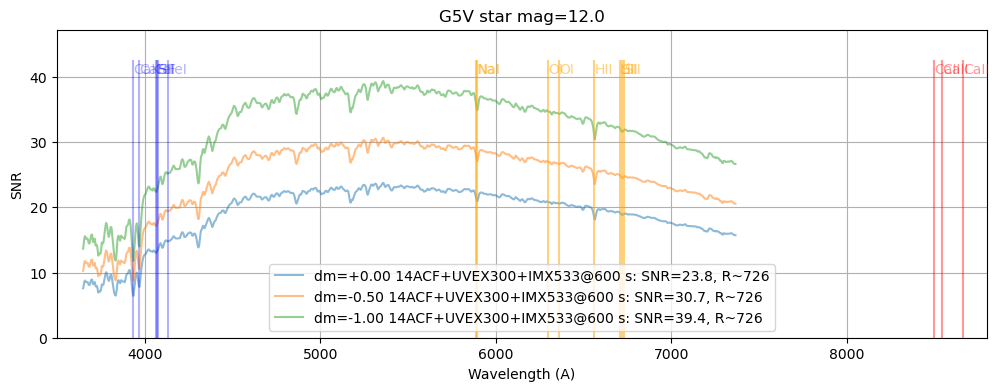

In [5]:
instrumentation = [(ACF14, UVEX300, IMX533, 600*u.second, 0),
                   (ACF14, UVEX300, IMX533, 600*u.second, -0.50),
                   (ACF14, UVEX300, IMX533, 600*u.second, -1.00),
                   ]
compare_instrumentation(instrumentation)

# Compare Detectors

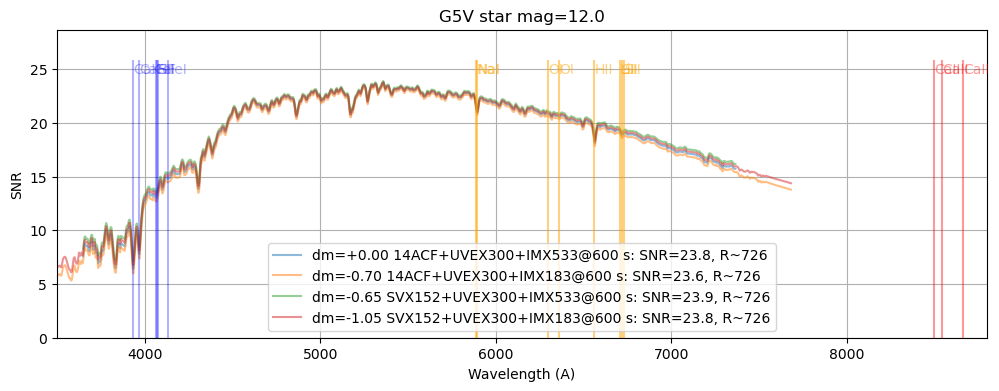

In [6]:
instrumentation = [(ACF14, UVEX300, IMX533, 600*u.second, 0),
                   (ACF14, UVEX300, IMX183, 600*u.second, -0.70),
                   (SVX152, UVEX300, IMX533, 600*u.second, -0.65),
                   (SVX152, UVEX300, IMX183, 600*u.second, -1.05),
                   ]
compare_instrumentation(instrumentation)

# Compare Telescopes

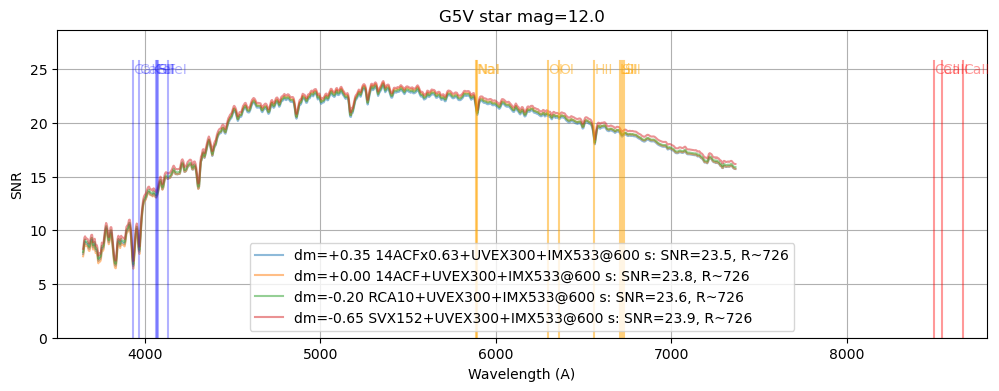

In [7]:
instrumentation = [(ACF14reduced, UVEX300, IMX533, 600*u.second, +0.35),
                   (ACF14, UVEX300, IMX533, 600*u.second, 0),
                   (RCA10, UVEX300, IMX533, 600*u.second, -0.20),
                   (SVX152, UVEX300, IMX533, 600*u.second, -0.65),
                   ]
compare_instrumentation(instrumentation)


# Compare Spectrographs

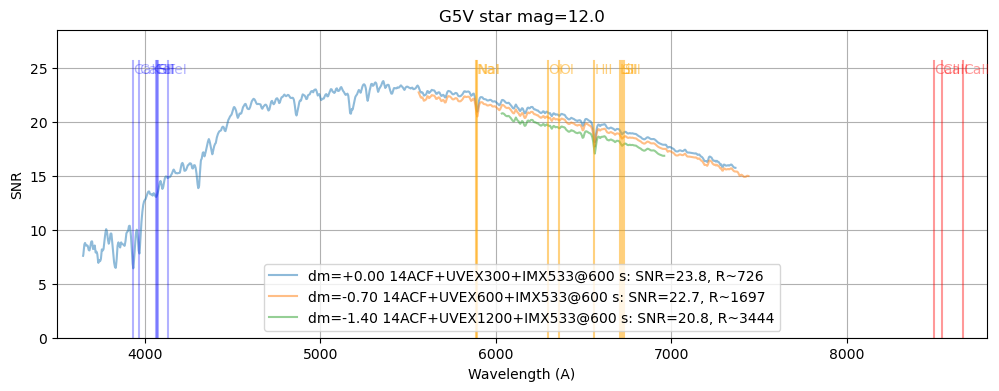

In [8]:
instrumentation = [(ACF14, UVEX300, IMX533, 600*u.second, 0.0),
                   (ACF14, UVEX600, IMX533, 600*u.second, -0.70),
                   (ACF14, UVEX1200, IMX533, 600*u.second, -1.40),
                   ]
compare_instrumentation(instrumentation)